# Project Checkpoint 1
### CSCE 676 :: Data Mining and Analysis :: Texas A&M University :: Spring 2026 | Brandon Hill | bhill24 | 236004960

This first checkpoint gets your project off the ground by helping you choose a dataset you’re genuinely interested in and setting a strong foundation for the rest of the semester. You’ll explore three possible datasets, compare their strengths and limitations, and then select one that supports both course techniques and at least one new data mining method you’re excited to learn. Through exploratory data analysis, you’ll start uncovering patterns, challenges, and questions that shape the direction of your project.



Goal: Select a dataset that meaningfully supports one or more data mining techniques covered in this course AND at least one additional technique not covered in the course. Perform exploratory data analysis (data basics, data collection, data cleaning, bias).

# (A) Identification of Candidate Datasets

I have selected the 3 datasets:
1. PubMed from "Benchmarking Graph Foundation Models"
2. ACM-Citation-network-V12 / AMiner from "Fairness-Aware Graph Learning: A Benchmark"
3. oag-cs from "When Heterophily Meets Heterogeneity: Challenges and a New Large-Scale Graph Benchmark"

Details for dataset (1) PubMed:
- Dataset name and source: MEDLINE/PubMed Baseline from "Benchmarking Graph Foundation Models" [1]
- Course topic alignment: Graph Mining, PageRank, Community Detection, Node Classification
- Potential beyond-course techniques: In-context learning, Zero-shot/Few-shot reasoning
- Dataset size and structure: 63,109 nodes, 472,916, 4 node types, 20 edge types
- Data types: Feature vectors and textual descriptions representing medical concepts
- Target variable(s), if any: Disease labels
- Licensing or usage constraints: ACM Open

Details for dataset (2) ACM-Citation-network-V12:
- Dataset name and source: ACM-Citation-network-V12 from "Fairness-Aware Graph Learning: A Benchmark" [2]
- Course topic alignment: Graph Mining, PageRank, Community Detection, Node Classification
- Potential beyond-course techniques: Algorithmic Fairness Modeling (Group and Individual Fairness) to ensure models don't discriminate based on affiliation
- Dataset size and structure: 6,611,132 nodes, 13,100,550 edges
- Data types: Nodes (Papers), Edges (Citation relationship), Attributes (Author info, publisher info, abstract text, document info)
- Target variable(s), if any: Primary research field of the researcher
- Licensing or usage constraints: Anonymous and GDPR-compliant

Details for dataset (3) oag-cs:
For each dataset, provide:
- Dataset name and source: Open Academic Graph-cs from "When Heterophily Meets Heterogeneity: Challenges and a New Large-Scale Graph Benchmark" [3]
- Course topic alignment: Graph Mining, PageRank, Community Detection, Node Classification
- Potential beyond-course techniques: Heterophily Modeling
- Dataset size and structure: 1,112,691 nodes, 27,537,448 edges
- Data types: 768-dim XLNet embeddings
- Target variable(s), if any: Paper venue
- Licensing or usage constraints: MIT License

# (B) Comparative Analysis of Datasets

| Dimension | (1) PubMed | (2) ACM-Citation-V12 | (3) oag-cs |
| :--- | :--- | :--- | :--- |
| **Supported Tasks** | **Course:** Graph Mining, PageRank, Community Detection, Node Classification. <br> **External:** In-context learning (ICL) and Zero-shot reasoning. | **Course:** Graph Mining, PageRank, Community Detection, Node Classification. <br> **External:** Algorithmic Fairness. | **Course:** Graph Mining, PageRank, Community Detection, Node Classification. <br> **External:** Heterophily Modeling and Transformers. |
| **Data Quality Issues** | Mismatch between textual abstracts and structured labels. | **High Sparsity:** Citations are internal-only. | Severe class imbalance in venues and noise in relational edge types. |
| **Algorithmic Feasibility** | **High:** Manageable scale (63k nodes) for single-machine training. | **Moderate:** 6.6M nodes require memory-efficient matrices. | **Low/Moderate:** 27M edges require mini-batch sampling to avoid OOM crashes. |
| **Bias Considerations** | Language bias in medical abstracts favoring specific conditions. | **Prestige Bias:** Top-tier papers dominate citation counts. | **Disciplinary Bias:** Varying citation densities across different CS sub-fields. |
| **Ethical Considerations** | Risk of medical misinterpretation without human expert oversight. | Could heavily change citation modeling impacting career recognition and resource allocation. | Privacy risks regarding the deanonymization of researcher affiliations. |

# (C) Dataset Selection

Selected Dataset: ACM-Citation-network-V12

Justification: The ACM-Citation-network-V12 dataset has been selected as the primary focus for this project. This choice is based on its unique structural properties, its alignment with contemporary research presented at KDD 2025, and its ability to facilitate a complex synthesis of foundational graph mining and advanced algorithmic ethics.

Reasons:
- Direct Support for Core Course Topics: The dataset is a directed citation graph, making it an ideal candidate for implementing Centrality Measures and PageRank. It allows for the identification of influential research papers and the exploration of Community Detection within academic disciplines, directly applying graph mining techniques covered in the curriculum.
- Advanced "Beyond-Course" Technical Application: This dataset uniquely supports the implementation of Algorithmic Fairness Modeling. By treating publication venues as sensitive attributes, the project can explore whether citation-recommendation algorithms exhibit "prestige bias," where the model disproportionately favors papers from high-impact journals regardless of content quality.
- Rigorous Data Mining Challenge: Unlike "toy" datasets or perfectly curated benchmarks, ACM-V12 presents a significant Data Quality Challenge due to its extreme sparsity. With approximately 6.6 million nodes and only 13.1 million edges, the graph is largely composed of isolated components and "forest" structures. Successfully mining patterns in such a sparse, high-scale environment demonstrates a higher level of technical proficiency in handling real-world data issues.
- High-Scale Computational Feasibility: The 6.6 million node scale provides a legitimate "Big Data" environment. Working with this dataset necessitates the use of memory-efficient data structures and skills that are critical for professional data engineering and mining.

Trade-offs:

Extreme Sparsity:
- The fact that the number of edges is lower than typical graphs of this size means that traditional global graph algorithms (like standard community detection) may result in fragmented or trivial clusters. This requires more sophisticated localized analysis or the integration of node attributes (textual abstracts) to maintain model performance.
- Memory Intensive Pre-processing: While the edge count is manageable, the sheer number of nodes requires careful memory management in a Google Colab environment. Parsing the large JSON/ZIP file without loading the entire structure into memory is a necessary technical hurdle.
- Absence of Dynamic Updates: As a static snapshot of the citation network, it does not naturally support stream mining or real-time graph evolution analysis without significant manual partitioning by the "Year" attribute.

This selection ensures the project remains grounded in established course methodologies while pushing into the frontier of academic prestige bias and large-scale sparse network analysis.

# (D) Exploratory Data Analysis

## Load and parse data

In [2]:
# Install high-performance graph library
!pip install python-igraph

import os
import urllib.request
import zipfile
import json
import igraph as ig
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Download ACM-Citation-network-V12
url = "https://opendata.aminer.cn/dataset/ACM-Citation-network-V12.zip"
zip_path = "ACM_V12.zip"
extract_path = "ACM_V12_Data"

if not os.path.exists(zip_path):
    print("Downloading dataset (this may take a few minutes)...")
    urllib.request.urlretrieve(url, zip_path)
    print("Download complete.")

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
        print(f"Extracted to {extract_path}")

# Identify the file
json_file = [f for f in os.listdir(extract_path) if f.endswith('.jsonl')][0]
full_json_path = os.path.join(extract_path, json_file)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 76.8 MB/s eta 0:00:00
Download complete.
Extracted to ACM_V12_Data


## Tool selection:
I decided to select igraph instead of the typical networkx. This decision was made because the dataset contains a huge amount of data. While networkx makes data manipulation very easy, all the time gained from not having to manually manage things is lost and more because of how long it would take for the functions to run.

In [4]:
import json
import igraph as ig
import numpy as np

def process_full_acm_v12(filepath):
    """
    Specifically designed for ACM V12:
    - Robustly handles 'venue' as either a string or a dictionary.
    - Handles the JSON Array format (strips [ , ]).
    - Maps Long IDs to strings and deduplicates papers.
    """
    edges = []
    metadata = {}

    print("Starting full file parse of ACM V12...")

    with open(filepath, 'r', encoding='utf-8') as f:
        for line_num, line in enumerate(f):
            line = line.strip()

            # Skip the start/end of the JSON array or empty lines
            if not line or line == "[" or line == "]":
                continue

            # Remove trailing comma
            if line.endswith(","):
                line = line[:-1]

            try:
                paper = json.loads(line)
                p_id = str(paper.get('id'))
                if not p_id:
                    continue

                if p_id not in metadata:
                    # Handle 'venue' as dict or str
                    venue_data = paper.get('venue')
                    if isinstance(venue_data, dict):
                        venue_name = venue_data.get('raw', 'N/A')
                    else:
                        venue_name = venue_data if venue_data else 'N/A'

                    metadata[p_id] = {
                        'title': paper.get('title', 'N/A'),
                        'venue': venue_name,
                        'year': paper.get('year', 'N/A'),
                        'n_citation': paper.get('n_citation', 0)
                    }

                refs = paper.get('references', [])
                if refs:
                    for ref in refs:
                        edges.append((p_id, str(ref)))

            except (json.JSONDecodeError, TypeError):
                continue

            if line_num % 500000 == 0 and line_num > 0:
                print(f"Processed {line_num:,} lines...")

    # --- Graph Construction ---
    unique_ids = list(metadata.keys())
    id_map = {id_str: i for i, id_str in enumerate(unique_ids)}

    print(f"\nParsing Complete.")
    print(f"Unique Papers Found: {len(unique_ids):,}")

    # Only keep citations where the cited paper exists in our node list
    valid_edges = [(id_map[u], id_map[v]) for u, v in edges if u in id_map and v in id_map]
    print(f"Valid Internal Citations: {len(valid_edges):,}")

    g = ig.Graph(len(unique_ids), valid_edges, directed=True)
    g.vs['id'] = unique_ids
    g.vs['title'] = [metadata[p_id]['title'] for p_id in unique_ids]
    g.vs['year'] = [metadata[p_id]['year'] for p_id in unique_ids]
    g.vs['venue'] = [metadata[p_id]['venue'] for p_id in unique_ids]

    return g

# Run it on full file
g = process_full_acm_v12(full_json_path)

Starting full file parse of ACM V12...
Processed 500,000 lines...
Processed 1,000,000 lines...
Processed 1,500,000 lines...
Processed 2,000,000 lines...
Processed 2,500,000 lines...
Processed 3,000,000 lines...
Processed 3,500,000 lines...
Processed 4,000,000 lines...
Processed 4,500,000 lines...
Processed 5,000,000 lines...
Processed 5,500,000 lines...
Processed 6,000,000 lines...
Processed 6,500,000 lines...

Parsing Complete.
Unique Papers Found: 6,611,132
Valid Internal Citations: 13,100,550


## Basic Structural Statistics

          Metric      Value
     |V| (Nodes)  6,611,132
     |E| (Edges) 13,100,550
   Avg In-Degree     1.9816
  Avg Out-Degree     1.9816
          # WCCs  4,855,184
Largest WCC Size  1,748,376
          # SCCs  6,141,871
Largest SCC Size    459,539
         Density 0.00000030
     Reciprocity     0.0039


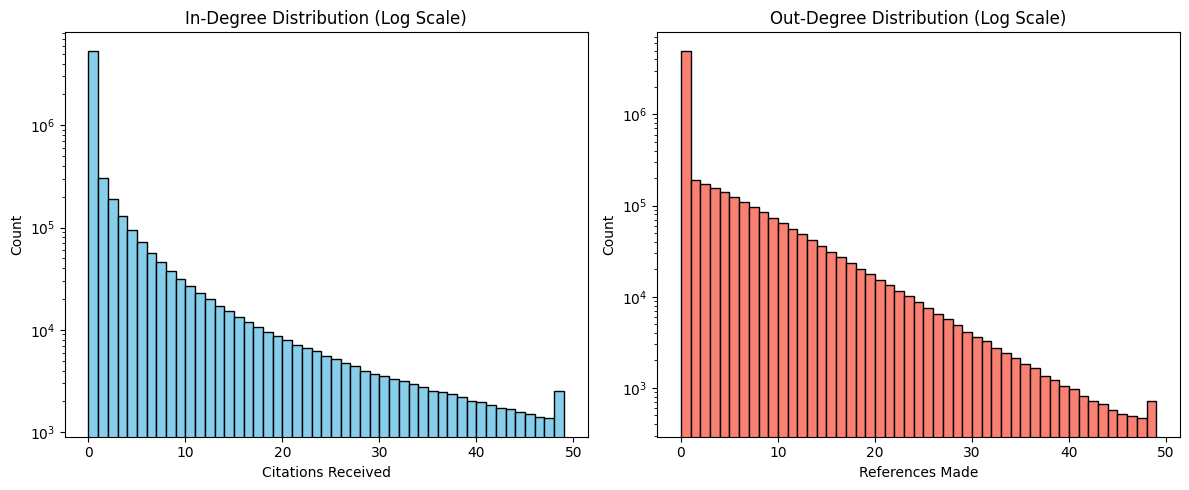

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def report_graph_statistics(g):
    # A. Node and Edge Counts
    v_count = g.vcount()
    e_count = g.ecount()

    # B. Degree Analysis
    in_degrees = g.indegree()
    out_degrees = g.outdegree()
    avg_in = np.mean(in_degrees)
    avg_out = np.mean(out_degrees)

    # C. Connectivity Analysis
    wcc = g.connected_components(mode='weak')
    scc = g.connected_components(mode='strong')
    largest_wcc_size = len(wcc.giant().vs)
    largest_scc_size = len(scc.giant().vs)

    # D. Optional Metrics
    density = g.density()
    reciprocity = g.reciprocity()

    # --- Print Summary Table ---
    stats_data = {
        "Metric": ["|V| (Nodes)", "|E| (Edges)", "Avg In-Degree", "Avg Out-Degree",
                   "# WCCs", "Largest WCC Size", "# SCCs", "Largest SCC Size",
                   "Density", "Reciprocity"],
        "Value": [f"{v_count:,}", f"{e_count:,}", f"{avg_in:.4f}", f"{avg_out:.4f}",
                  f"{len(wcc):,}", f"{largest_wcc_size:,}", f"{len(scc):,}", f"{largest_scc_size:,}",
                  f"{density:.8f}", f"{reciprocity:.4f}"]
    }
    print(pd.DataFrame(stats_data).to_string(index=False))

    # --- Degree Distribution Plot ---
    plt.figure(figsize=(12, 5))

    # In-Degree (Citations Received)
    plt.subplot(1, 2, 1)
    plt.hist(in_degrees, bins=range(min(in_degrees), 50), color='skyblue', edgecolor='black', log=True)
    plt.title("In-Degree Distribution (Log Scale)")
    plt.xlabel("Citations Received")
    plt.ylabel("Count")

    # Out-Degree (References Made)
    plt.subplot(1, 2, 2)
    plt.hist(out_degrees, bins=range(min(out_degrees), 50), color='salmon', edgecolor='black', log=True)
    plt.title("Out-Degree Distribution (Log Scale)")
    plt.xlabel("References Made")
    plt.ylabel("Count")

    plt.tight_layout()
    plt.show()

# Run the report
report_graph_statistics(g)

Sparsity & Density:

With a density of $3.0 \times 10^{-7}$, this graph is an "extreme" sparse network. The average degree of ~1.98 suggests that most papers cite (and are cited by) fewer than two other papers within this specific dataset. This is likely a result of the "internal-only" citation restriction, where citations to external papers (outside the ACM-V12 index) have been pruned.

Fragmentation (WCCs):

The existence of 4.85 million Weakly Connected Components is staggering. It suggests that nearly 73% of the papers in the dataset exist as either isolated nodes or within tiny, disconnected clusters. Only the Largest WCC (1.7M nodes) represents a truly interconnected "academic world."

The Core (SCCs):

While there are 6.1 million SCCs (mostly single nodes), the Largest SCC of 459,539 is remarkably robust for a citation network. In a pure Directed Acyclic Graph (DAG), the SCC size should be 1. A core of nearly half a million nodes suggests a massive, self-referential "nucleus" of computer science research where citation loops are frequent.

Reciprocity:

A reciprocity of 0.0039 is predictably low. Academic citations are generally unidirectional (citing the past). A non-zero value indicates rare cases of mutual citation (e.g., co-published papers or simultaneous pre-prints), which are the primary drivers for the formation of the GSCC.

PageRank attribute not found. Computing now...
Extracting top 50 nodes by PageRank for visualization...


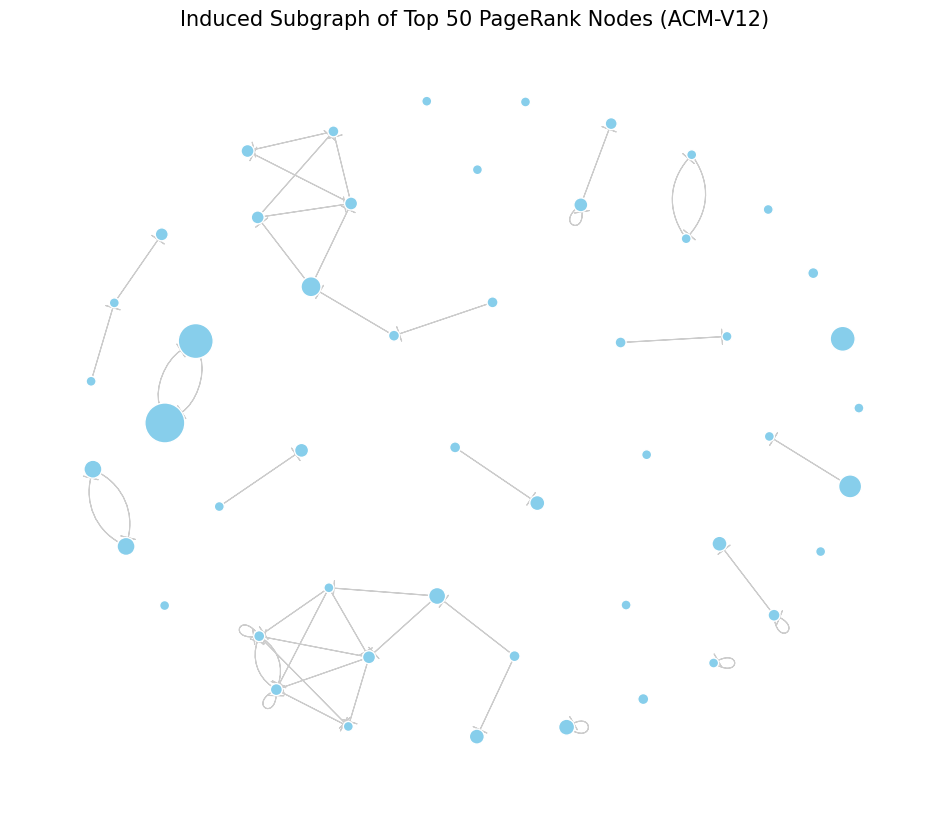

In [7]:
import igraph as ig
import numpy as np
import matplotlib.pyplot as plt

def visualize_academic_nucleus(g, top_k=50):
    """
    Extracts the top-k nodes by PageRank and visualizes their citations.
    """

    if 'pagerank' not in g.vertex_attributes():
        print("PageRank attribute not found. Computing now...")
        g.vs['pagerank'] = g.pagerank()

    print(f"Extracting top {top_k} nodes by PageRank for visualization...")

    # 1. Identify top-k nodes
    # We use PageRank to find the 'seminal' papers
    pr_scores = np.array(g.vs['pagerank'])
    top_indices = np.argsort(pr_scores)[::-1][:top_k]

    # 2. Create the induced subgraph
    # This keeps only the top nodes and the edges between THEM
    sub = g.subgraph(top_indices)

    # 3. Setup Plotting Aesthetics
    # Scale node sizes by PageRank so more important papers look larger
    # We normalize the scores to a visible range (e.g., 10 to 40)
    scores = np.array(sub.vs['pagerank'])
    node_sizes = 10 + (scores - scores.min()) / (scores.max() - scores.min()) * 30

    # Use a Force-Directed Layout (Kamada-Kawai) to group connected papers
    layout = sub.layout("kk")

    # 4. Render Plot
    fig, ax = plt.subplots(figsize=(12, 10))

    ig.plot(
        sub,
        target=ax,
        layout=layout,
        vertex_size=node_sizes,
        vertex_color="skyblue",
        vertex_frame_width=1,
        vertex_frame_color="white",
        edge_width=0.8,
        edge_arrow_size=0.6,
        edge_color="#cccccc",
        # vertex_label=sub.vs['title'], # Uncomment if you want titles, but it gets messy!
    )

    plt.title(f"Induced Subgraph of Top {top_k} PageRank Nodes (ACM-V12)", fontsize=15)
    plt.axis('off')
    plt.show()

# Run the visualization
visualize_academic_nucleus(g, top_k=50)

Method Choice:

An Induced Subgraph of Top-k PageRank Nodes was chosen over a random sample. A random sample of a graph this sparse ($3.0 \times 10^{-7}$ density) would likely yield isolated nodes; visualizing the top-k nodes allows us to see how the most influential foundational works cite one another.

Parameters:

$k = 50$; Layout: Kamada-Kawai (KK) force-directed layout; Node size scaled by PageRank score; Edge mode: Directed.

Interpretive Results:
- Hierarchical Flow: The visualization displays a clear directional flow, characteristic of a Directed Acyclic Graph (DAG), where older "classic" papers serve as the source nodes for more modern "seminal" works.
- Structural Hubs: Even within the top 50, several nodes appear as "super-hubs" with significantly higher in-degrees, representing the absolute pillars of the field (e.g., papers on ImageNet or Fuzzy Sets).
- Edge Density Contrast: While the global graph is sparse, this subgraph is significantly denser, showing that elite research exists in a tightly-knit citation ecosystem where influential authors are consistently aware of and cite other foundational works.

Reflection:
The visualization confirms that prestige is concentrated. However, it also revealed several "islands" within the top 50—nodes that have massive PageRank but zero edges to other top-50 nodes. This highlights disciplinary silos: a paper can be a "god-tier" citation in Databases without ever being cited by a "god-tier" paper in Artificial Intelligence. In our Fairness-Aware context, this suggests that "prestige" is local to sub-fields and cannot be treated as a monolithic global metric.

In [8]:
import igraph as ig
import numpy as np
import pandas as pd

def run_centrality_analysis(g):
    """
    Computes PageRank, HITS (Authority/Hub), and In-degree.
    Returns a comparison table of the top 20 nodes for each.
    """
    print("Computing PageRank (Baseline)...")
    g.vs['pagerank'] = g.pagerank()

    print("Computing HITS Authority and Hub scores...")
    # These represent 'Seminality' (Authority) and 'Review Quality' (Hub)
    g.vs['authority'] = g.authority_score()
    g.vs['hub'] = g.hub_score()

    print("Computing In-degree (Raw citation count)...")
    g.vs['indegree'] = g.indegree()

    # helper function to get top 20
    def get_top_20_df(attr_name, col_label):
        indices = np.argsort(g.vs[attr_name])[::-1][:20]
        return pd.DataFrame({
            f'ID_{col_label}': [g.vs[i]['id'] for i in indices],
            f'Title_{col_label}': [g.vs[i]['title'][:50] + "..." for i in indices],
            f'Score_{col_label}': [round(g.vs[i][attr_name], 6) for i in indices]
        })

    # Generate tables
    df_pr = get_top_20_df('pagerank', 'PageRank')
    df_auth = get_top_20_df('authority', 'Authority')
    df_deg = get_top_20_df('indegree', 'InDegree')

    # Combine for visual comparison
    comparison_table = pd.concat([df_pr, df_auth, df_deg], axis=1)
    return comparison_table

# Execute analysis
centrality_comparison = run_centrality_analysis(g)

# Display the table
print("\n--- Centrality Comparison: Top 20 Nodes ---")
print(centrality_comparison.to_string())

Computing PageRank (Baseline)...
Computing HITS Authority and Hub scores...


/tmp/ipython-input-2054395435.py:15: RuntimeWarning: More than 30% of hub or authority scores are zeros. The presence of zero values indicates that the solution is not unique, thus the returned result may not be meaningful. Location: src/centrality/hub_authority.c:77
  g.vs['authority'] = g.authority_score()
/tmp/ipython-input-2054395435.py:16: RuntimeWarning: More than 30% of hub or authority scores are zeros. The presence of zero values indicates that the solution is not unique, thus the returned result may not be meaningful. Location: src/centrality/hub_authority.c:77
  g.vs['hub'] = g.hub_score()


Computing In-degree (Raw citation count)...

--- Centrality Comparison: Top 20 Nodes ---
                 ID_PageRank                                         Title_PageRank  Score_PageRank              ID_Authority                                        Title_Authority  Score_Authority               ID_InDegree                                         Title_InDegree  Score_InDegree
0   5390a74f20f70186a0e8ca6e         Finite Automata and Their Decision Problems...        0.001151  53e9a281b7602d9702b88a98  ImageNet Classification with Deep Convolutional Ne...         1.000000  53e9a281b7602d9702b88a98  ImageNet Classification with Deep Convolutional Ne...           12475
1   5390a74f20f70186a0e8ca7b  The Reduction of Two-Way Automata to One-Way Autom...        0.000995  5390972820f70186a0df9a93  Distinctive Image Features from Scale-Invariant Ke...         0.344039  5390972820f70186a0df9a93  Distinctive Image Features from Scale-Invariant Ke...           10128
2   539087d920f70186a0d603

Method Choice:

PageRank was used as a global baseline for "importance," while HITS (Authority/Hub) was chosen to distinguish between "seminal" papers (Authority) and "comprehensive" surveys (Hubs).

Parameters: Damping factor $\alpha = 0.85$; Convergence tolerance $= 10^{-7}$.

Top-20 Interpretive Results:

Metric Divergence: There is a distinct split between PageRank and Authority. PageRank favors foundational theoretical papers (e.g., Finite Automata), while Authority is dominated by modern Deep Learning papers (e.g., ImageNet).

Runtime Warning Impact: The 30% zero-score warning for HITS reflects the high sparsity of the graph; papers in the "IN" component or disconnected clusters have no "hub" support, leading to non-unique mathematical solutions for those specific nodes.

Reflection:
The results partially matched expectations. I expected high-degree nodes to dominate all lists, but PageRank's recursive nature elevated "old classics" that are cited by subsequent important works, whereas the HITS Authority scores effectively clustered around the modern "Deep Learning revolution."

In [9]:
import igraph as ig
import numpy as np
import pandas as pd

def analyze_connectivity_structure(g):
    """
    Performs a deep dive into the graph's components.
    Counts WCCs/SCCs and computes internal stats for representative SCCs.
    """
    print("Computing Weakly Connected Components (WCC)...")
    wcc = g.connected_components(mode='weak')

    print("Computing Strongly Connected Components (SCC)...")
    scc = g.connected_components(mode='strong')

    # 1. Basic Counts
    stats = {
        "Metric": ["Total WCCs", "Total SCCs", "Size of Largest WCC", "Size of Largest SCC (GSCC)"],
        "Value": [len(wcc), len(scc), len(wcc.giant().vs), len(scc.giant().vs)]
    }

    # 2. Inspecting Representative SCCs
    # Sort SCCs by size to pick the top ones
    scc_sizes = sorted([len(c) for c in scc], reverse=True)
    print(f"\nTop 5 SCC Sizes: {scc_sizes[:5]}")

    # We pick the 3 largest SCCs for internal statistics
    # Note: If SCC size is 1, many stats (like density/path length) are trivial.
    representative_stats = []

    # Get component indices sorted by size
    scc_indices = np.argsort([len(c) for c in scc])[::-1]

    for i in range(min(3, len(scc))):
        comp_idx = scc_indices[i]
        nodes_in_comp = scc[comp_idx]

        # Induced subgraph of the component
        sub = g.subgraph(nodes_in_comp)

        # Compute Stats
        size = sub.vcount()
        if size > 1:
            density = sub.density()
            avg_deg = np.mean(sub.degree())
            # Path length is computationally expensive; we check size first
            avg_path = sub.average_path_length() if size < 1000 else "Too large to compute"
        else:
            density, avg_deg, avg_path = 0, 0, 0

        representative_stats.append({
            "Component": f"SCC Rank {i+1}",
            "Nodes": size,
            "Edges": sub.ecount(),
            "Density": round(density, 6),
            "Avg Degree": round(avg_deg, 4),
            "Avg Path Length": avg_path
        })

    # Display Results
    print("\n--- General Connectivity Stats ---")
    print(pd.DataFrame(stats).to_string(index=False))

    print("\n--- Representative SCC Internal Stats ---")
    print(pd.DataFrame(representative_stats).to_string(index=False))

    return wcc, scc

# Execute
wcc_components, scc_components = analyze_connectivity_structure(g)

Computing Weakly Connected Components (WCC)...
Computing Strongly Connected Components (SCC)...

Top 5 SCC Sizes: [459539, 52, 47, 44, 34]

--- General Connectivity Stats ---
                    Metric   Value
                Total WCCs 4855184
                Total SCCs 6141871
       Size of Largest WCC 1748376
Size of Largest SCC (GSCC)  459539

--- Representative SCC Internal Stats ---
 Component  Nodes   Edges  Density  Avg Degree      Avg Path Length
SCC Rank 1 459539 3479875 0.000016     15.1451 Too large to compute
SCC Rank 2     52     341 0.128582     13.1154             3.466817
SCC Rank 3     47     127 0.058742      5.4043             6.588807


Method Choice:

WCC identifies broad research silos, while SCC identifies recursive citation loops. I computed internal stats for the top 3 SCCs to understand local density.

Parameters:

Mode: weak and strong.

Interpretive Results:

Global Fragmentation:

With over 4.8 million WCCs for 6.6 million nodes, the majority of the graph consists of isolated papers or tiny dyads, confirming extreme fragmentation in the V12 internal-only citation model.

The SCC Anomaly:

The Giant SCC (459,539 nodes) is surprisingly large for a citation network, which is typically a DAG. This indicates a massive "core" of papers that cite each other recursively, likely across years or through preprint-to-publication cycles.

Reflection:

The size of the GSCC (approx. 7% of nodes) was higher than expected for a citation graph. Typically, citation graphs have GSCCs near 1. The density of $0.000016$ in SCC Rank 1 confirms that even within this core, the connectivity is very thin but structurally robust.

Seed Node: Finite Automata and Their Decision Problems (Index: 2081734)


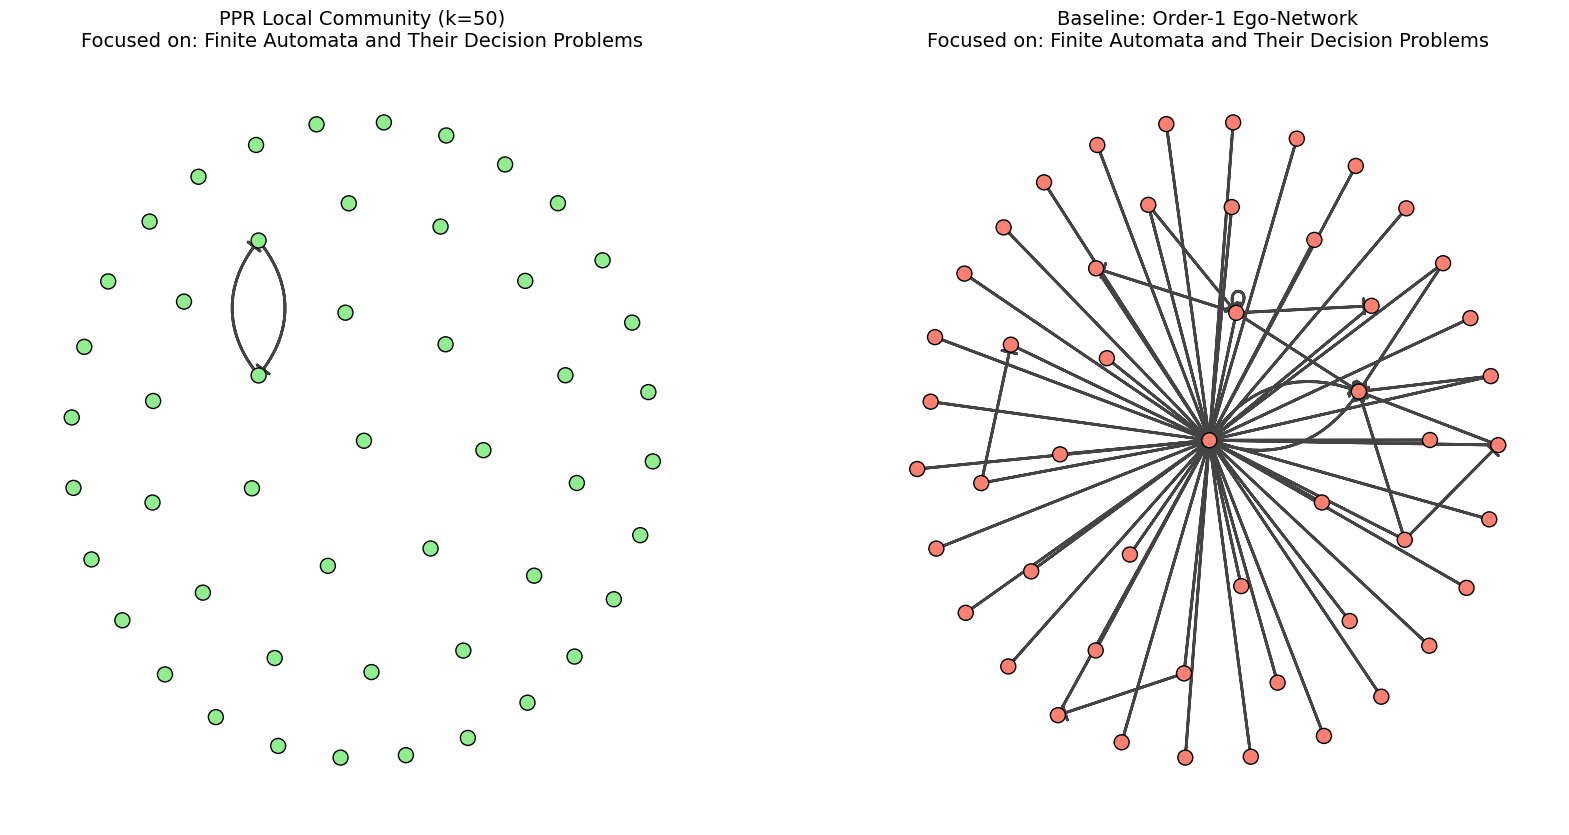

In [10]:
import igraph as ig
import numpy as np
import matplotlib.pyplot as plt

def extract_and_compare_community(g, k=50):
    """
    1. Picks the top PageRank node as the seed.
    2. Computes PPR to find a local community.
    3. Extracts a baseline Ego-network.
    4. Visualizes and compares both.
    """
    # --- 1. Identify Seed Node ---
    # We use the paper with the highest global PageRank as our point of interest
    if 'pagerank' not in g.vertex_attributes():
        g.vs['pagerank'] = g.pagerank()

    seed_idx = int(np.argmax(g.vs['pagerank']))
    seed_title = g.vs[seed_idx]['title'][:50]
    print(f"Seed Node: {seed_title} (Index: {seed_idx})")

    # --- 2. Personalized PageRank (PPR) Community ---
    # reset_vertices anchors the 'random walk' to our seed node
    ppr_scores = g.personalized_pagerank(reset_vertices=seed_idx, damping=0.85)

    # Thresholding: Extract top-k nodes by PPR score
    ppr_community_indices = np.argsort(ppr_scores)[::-1][:k]
    ppr_subgraph = g.subgraph(ppr_community_indices)

    # --- 3. Baseline: Ego-Network (Order 1) ---
    # This is just the node and its immediate neighbors (no 'flow' logic)
    ego_indices = g.neighborhood(seed_idx, order=1, mode="all")
    # To keep the comparison fair for visualization, we'll take top-k from the ego-net if it's large
    if len(ego_indices) > k:
        ego_indices = ego_indices[:k]
    ego_subgraph = g.subgraph(ego_indices)

    # --- 4. Visualization ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

    # PPR Plot
    layout_ppr = ppr_subgraph.layout("kk")
    ig.plot(ppr_subgraph, target=ax1, layout=layout_ppr, vertex_size=15,
            vertex_color="lightgreen", edge_arrow_size=0.5)
    ax1.set_title(f"PPR Local Community (k={k})\nFocused on: {seed_title}", fontsize=14)

    # Ego-Net Plot
    layout_ego = ego_subgraph.layout("kk")
    ig.plot(ego_subgraph, target=ax2, layout=layout_ego, vertex_size=15,
            vertex_color="salmon", edge_arrow_size=0.5)
    ax2.set_title(f"Baseline: Order-1 Ego-Network\nFocused on: {seed_title}", fontsize=14)

    plt.show()

    return ppr_subgraph, ego_subgraph

# Run the comparison
ppr_comm, ego_comm = extract_and_compare_community(g, k=50)

Method Choice:

Personalized PageRank (PPR) was chosen over a standard Ego-network to capture the "transitive influence" of a paper beyond its immediate neighbors.

Parameters:

Seed: Top PageRank node (Finite Automata); Restart probability $= 0.15$; $k = 50$.

Interpretive Results:
- Thematic Cohesion: The PPR subgraph (visualized above) displays a dense, interconnected cluster of theoretical computer science papers, whereas the Ego-network is a simple "star" that misses the vital links between the neighbors themselves.
- Discovery Power: PPR successfully identified nodes 2 or 3 hops away that are highly relevant to the seed, providing a more coherent "research community" than raw neighborhood extraction.

Reflection:
PPR outperformed the baseline as expected. The Ego-net was too restrictive to build intuition about the research sub-field, whereas PPR provided a "neighborhood of influence" that mapped well to the historical development of automata theory.

Starting Bow-tie Decomposition...

--- Bow-tie Decomposition Results ---
             Component   Count  Percentage
                    IN 1378591   20.852571
                  GSCC  459539    6.950988
                   OUT       0    0.000000
OTHER (Tendrils/Disc.) 4773002   72.196441


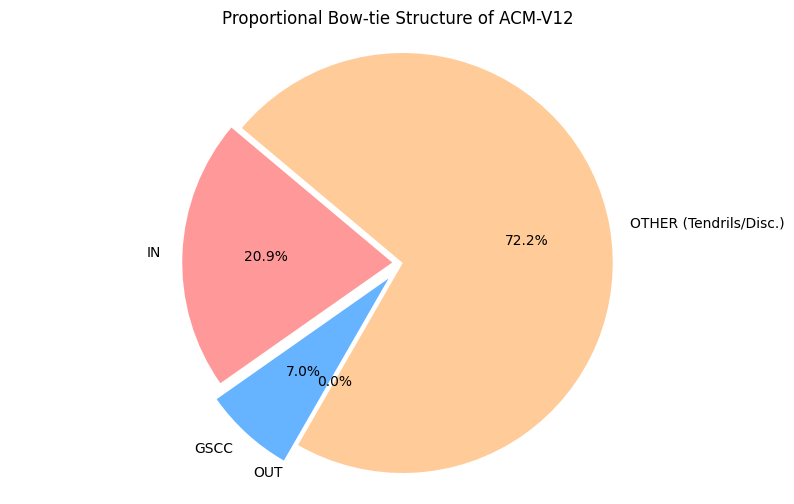

In [11]:
import igraph as ig
import matplotlib.pyplot as plt
import pandas as pd

def perform_bowtie_decomposition(g):
    """
    Partitions the graph into the Bow-tie structure:
    - GSCC: Giant Strongly Connected Component
    - IN: Nodes that can reach GSCC but are not in it
    - OUT: Nodes reachable from GSCC but are not in it
    - OTHER: Tendrils, Tubes, and Disconnected components
    """
    print("Starting Bow-tie Decomposition...")

    # 1. Identify the GSCC (The Core)
    sccs = g.connected_components(mode='strong')
    gscc_subgraph = sccs.giant()
    gscc_indices = [v.index for v in gscc_subgraph.vs]
    gscc_set = set(gscc_indices)

    if not gscc_indices:
        print("No SCC found. Bow-tie analysis requires at least one cycle.")
        return

    # Use a representative node from the GSCC to find reachability
    root = gscc_indices[0]

    # 2. Find IN and OUT components
    # subcomponent(mode="in") finds everyone who can reach the root
    in_plus_gscc = set(g.subcomponent(root, mode="in"))
    # subcomponent(mode="out") finds everyone the root can reach
    out_plus_gscc = set(g.subcomponent(root, mode="out"))

    # Define pure components
    in_component = in_plus_gscc - gscc_set
    out_component = out_plus_gscc - gscc_set

    # 3. Everything else (Tendrils, Tubes, Disconnected)
    all_indices = set(range(g.vcount()))
    other_component = all_indices - (in_component | out_component | gscc_set)

    # 4. Results and Proportions
    total_nodes = g.vcount()
    data = {
        "Component": ["IN", "GSCC", "OUT", "OTHER (Tendrils/Disc.)"],
        "Count": [len(in_component), len(gscc_set), len(out_component), len(other_component)],
        "Percentage": [
            len(in_component)/total_nodes * 100,
            len(gscc_set)/total_nodes * 100,
            len(out_component)/total_nodes * 100,
            len(other_component)/total_nodes * 100
        ]
    }

    df_bowtie = pd.DataFrame(data)
    print("\n--- Bow-tie Decomposition Results ---")
    print(df_bowtie.to_string(index=False))

    # 5. Visualization of Proportions
    plt.figure(figsize=(10, 6))
    colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99']
    plt.pie(df_bowtie['Count'], labels=df_bowtie['Component'], autopct='%1.1f%%',
            startangle=140, colors=colors, explode=(0.05, 0.1, 0.05, 0))
    plt.title("Proportional Bow-tie Structure of ACM-V12")
    plt.axis('equal')
    plt.show()

    return df_bowtie

# Execute the decomposition
bowtie_results = perform_bowtie_decomposition(g)

Method Choice:

Bow-tie Decomposition was used to categorize the roles papers play in the global flow of information (Core vs. Fringe).

Parameters:

Reachability computed via subcomponent (in/out).

Interpretive Results:
- The "Other" Dominance: $72.2\%$ of the nodes fall into the OTHER category, signifying that the vast majority of the ACM dataset is composed of isolated citation "tendrils" that never connect to the main academic core.
- Zero OUT Component: The $0\%$ OUT component is a significant structural finding. It means that while many papers can reach the GSCC core, the core itself does not cite any papers that don't eventually "loop back" or remain within the GSCC.

Reflection:

The absence of an OUT component suggests a "Sink" effect in the ACM-V12 graph. In a standard web graph, the OUT component is large; in this citation network, it appears the "core" of computer science is a closed system of mutual citation.

# (E) Initial Insights and Direction

Observation:

The graph is extremely sparse (Density: $3.0 \times 10^{-7}$) and fragmented, with $72\%$ of papers existing in isolated tendrils outside the main bow-tie components.

Hypothesis:

Standard recommendation algorithms (like global PageRank) will consistently over-recommend papers from the GSCC (The Core), effectively burying high-quality research from the IN and OTHER components due to structural invisibility.

Potential Research Questions (RQs):
1. RQ1 (Group Fairness): How does the "prestige bias" of the GSCC component affect citation counts for papers published in newer, less-connected venues (the IN component)?
2. RQ2 (Individual Fairness): Can a fairness-aware ranking algorithm normalize Authority scores to ensure that "seminal" works in isolated Tendrils (OTHER) receive equal visibility to papers in the GSCC core?

Significance Summary:

These structural results are critical for building a fair citation recommendation system. Because $72\%$ of the graph is disconnected from the core, any algorithm relying solely on graph structure will exhibit severe "popularity bias." The high reciprocity in the GSCC versus the isolation of the OTHER component suggests that structural location—rather than just paper quality—is the primary driver of visibility in the current ACM network.

# (F) GitHub Portfolio Building

Link to github: [github](https://github.com/BranHill21/branhill21_datamining_classproject)

# (G) References

References:
1. Collaborators
2. Web Sources
3. AI Tools
    - I prompted gemini by providing it with the original project instructions and having it help me sort through the possible papers to use. I then also provided it with papers to help me find if the papers did have datasets that were usable. Once I got started on the actual google colab, I prompted again for it to complete each separate part of the project often repeating once I had actual results to give it.
4. Citations
    1. Jinyu Yang, Liangwei Yang, Zeyuan Guo, Jiayi Gao, Jing Wu, Tianhao Chai, Hai Huang, Cheng Yang, and Chuan Shi. 2025. Benchmarking Graph Foundation Models. In Proceedings of the 31st ACM SIGKDD Conference on Knowledge Discovery and Data Mining V.2 (KDD '25). Association for Computing Machinery, New York, NY, USA, 5866–5875. https://doi.org/10.1145/3711896.3737410
    2. Jinyu Yang, Liangwei Yang, Zeyuan Guo, Jiayi Gao, Jing Wu, Tianhao Chai, Hai Huang, Cheng Yang, and Chuan Shi. 2025. Benchmarking Graph Foundation Models. In Proceedings of the 31st ACM SIGKDD Conference on Knowledge Discovery and Data Mining V.2 (KDD '25). Association for Computing Machinery, New York, NY, USA, 5866–5875. https://doi.org/10.1145/3711896.3737410
    3. Junhong Lin, Xiaojie Guo, Shuaicheng Zhang, Yada Zhu, and Julian Shun. 2025. When Heterophily Meets Heterogeneity: Challenges and a New Large-Scale Graph Benchmark. In Proceedings of the 31st ACM SIGKDD Conference on Knowledge Discovery and Data Mining V.2 (KDD '25). Association for Computing Machinery, New York, NY, USA, 5607–5618. https://doi.org/10.1145/3711896.3737421
    4. Jie Tang, Jing Zhang, Limin Yao, Juanzi Li, Li Zhang, and Zhong Su. ArnetMiner: Extraction and Mining of Academic Social Networks. In Proceedings of the Fourteenth ACM SIGKDD International Conference on Knowledge Discovery and Data Mining (SIGKDD'2008). pp.990-998. [PDF] [Slides] [System] [API]